# Palmer Penguins Modeling

Import the Palmer Penguins dataset and print out the first few rows.

Suppose we want to predict `bill_depth_mm` using the other variables in the dataset.

Which variables would we need to **dummify**?

In [1]:
!pip install palmerpenguins

zsh:1: command not found: pip


In [2]:
from palmerpenguins import load_penguins
penguins = load_penguins()

ModuleNotFoundError: No module named 'palmerpenguins'

In [ ]:
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


Let's use `bill_length_mm` to predict `bill_depth_mm`. Prepare your data and fit the following models on the entire dataset:

* Simple linear regression (e.g. straight-line) model
* Quadratic (degree 2 polynomial) model
* Cubic (degree 3 polynomial) model
* Degree 10 polynomial model

Make predictions for each model and plot your fitted models on the scatterplot.

In [ ]:
import pandas as pd

# Select relevant columns and drop rows with missing values
data = penguins[['bill_length_mm', 'bill_depth_mm']].dropna()
# Separate features (X) and target (y)
X = data[['bill_length_mm']]
y = data['bill_depth_mm']

display(data.head())

,bill_length_mm,bill_depth_mm
0,39.1,18.7
1,39.5,17.4
2,40.3,18.0
4,36.7,19.3
5,39.3,20.6


### Using different models to predict:


Importing libraries:

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression

Create a dataframe with original bill length and bill depth

In [ ]:
# Create a DataFrame with the original bill_length_mm and bill_depth_mm
predicted_df = pd.DataFrame({'bill_length_mm': X.values.flatten(), 'bill_depth_mm': y.values})

###### Simple linear regression

In [ ]:
# simple linear regression
model_liner = LinearRegression()
model_liner.fit(X,y)
y_pred_liner = model_linear.predict(X)

# add the predicted values for simple linear regression
predicted_df['linear_pred'] = y_pred_linear

Quadratic Model:

In [ ]:
#quadratic (degree 2 polynomial)
from sklearn.preprocessing import PolynomialFeatures

poly_2 = PolynomialFeatures(degree=2)
X_poly_2 = poly_2.fit_transform(X)
model_quadratic = LinearRegression()
model_quadratic.fit(X_poly_2, y)
y_pred_quadratic = model_quadratic.predict(X_poly_2)

# adding the predicted values of quadratic model into the dataframe
predicted_df['quadratic_pred'] = y_pred_quadratic

Cubic Model:

In [ ]:
# Cubic Model
poly_3 = PolynomialFeatures(degree=3, include_bias = False)
X_poly_3 = poly_3.fit_transform(X)

model_cubic = LinearRegression()
model_cubic.fit(X_poly_3, y)
y_pred_cubic = model_cubic.predict(X_poly_3)

# adding the predicted values of cubic model into the dataframe
predicted_df['cubic_pred'] = y_pred_cubic

NameError: name 'PolynomialFeatures' is not defined

Degree 10:

In [ ]:
# Degree 10 Polynomial Model
poly_10 = PolynomialFeatures(degree=10, bias)
X_poly_10 = poly_10.fit_transform(X)
model_degree_10 = LinearRegression()
model_degree_10.fit(X_poly_10, y)
y_pred_degree_10 = model_degree_10.predict(X_poly_10)

# adding the predicted values of degree 10 model into the dataframe
predicted_df['degree_10_pred'] = y_pred_degree_10

In [ ]:
# Display the first few rows of the new DataFrame
display(predicted_df.head())

,bill_length_mm,bill_depth_mm,linear_pred,quadratic_pred,cubic_pred,degree_10_pred
0,39.1,18.7,17.561136,17.484121,17.763289,18.385233
1,39.5,17.4,17.527128,17.392292,17.688565,18.263916
2,40.3,18.0,17.459111,17.223194,17.532171,17.959386
3,36.7,19.3,17.765187,18.136996,18.128998,18.487002
4,39.3,20.6,17.544132,17.437600,17.726273,18.327503


## Plotting

In [ ]:
import plotnine as p9

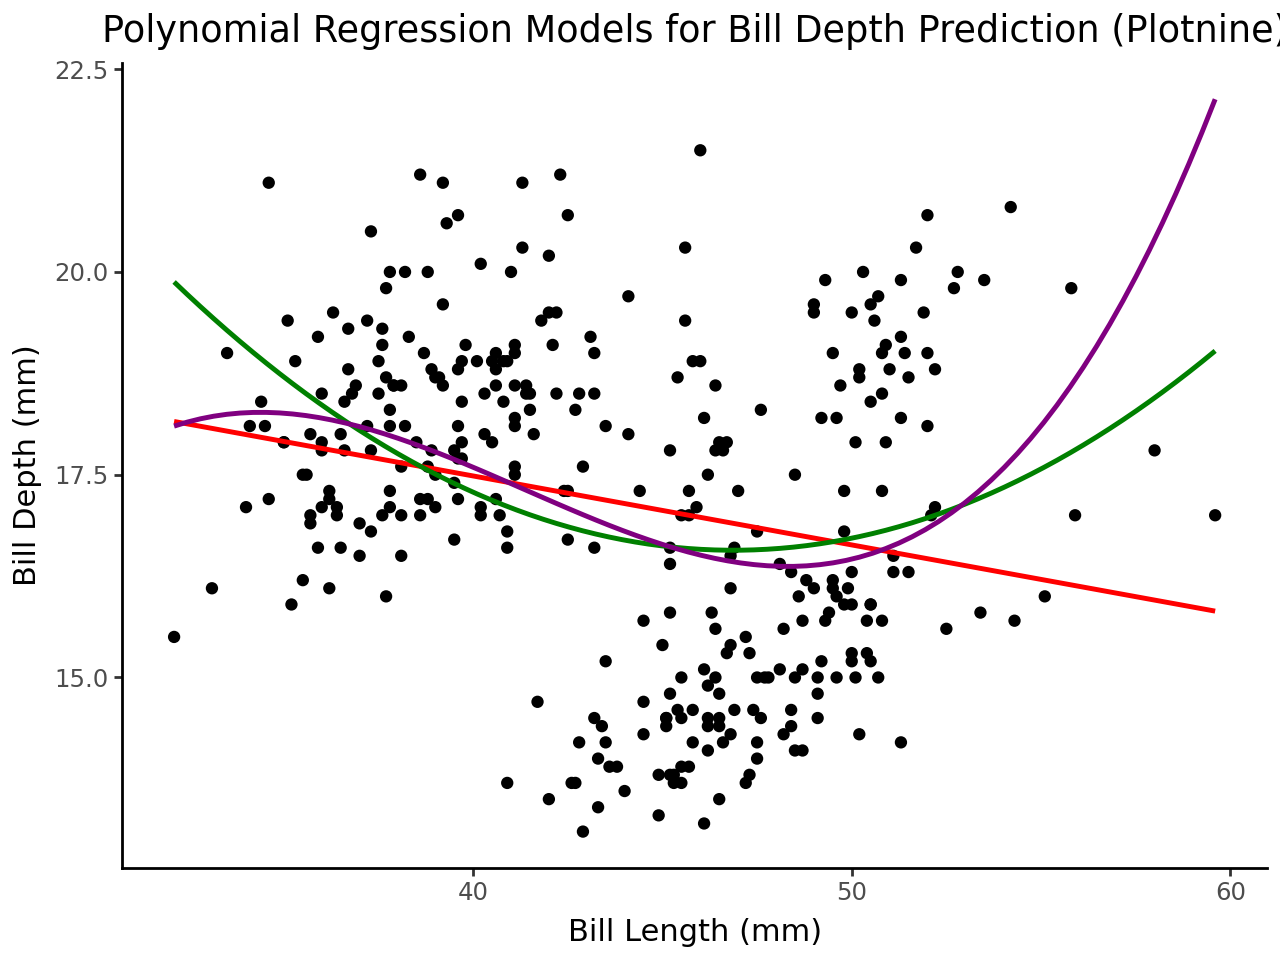

In [ ]:
from plotnine import ggplot, aes, geom_point, geom_smooth, labs, theme_classic

p = (ggplot(data, aes(x='bill_length_mm', y='bill_depth_mm'))
     + geom_point()
     + theme_classic())

# Add the fitted models as smooth lines
# Simple Linear Regression
p = p + geom_smooth(method='lm', se=False, color='red', linetype='solid')

# Quadratic Model (using formula for polynomial regression)
p = p + geom_smooth(method='lm', formula='y ~ x + I(x**2)', se=False, color='green', linetype='solid')

# Cubic Model (using formula for polynomial regression)
p = p + geom_smooth(method='lm', formula='y ~ x + I(x**2) + I(x**3)', se=False, color='purple', linetype='solid')

# Degree 10 Polynomial Model (using formula for polynomial regression)
# Note: Plotnine's geom_smooth might struggle with very high degree polynomials.
# A more robust approach for higher degrees would be to generate predictions
# from the fitted sklearn models and plot those as lines.
# For demonstration, let's try with formula up to degree 3, and explain
# how to plot higher degrees by generating predictions.

# Add labels and title
p = p + labs(x='Bill Length (mm)', y='Bill Depth (mm)', title='Polynomial Regression Models for Bill Depth Prediction (Plotnine)')

# Display the plot
p


* Are any of the models above underfitting the data? If so, which ones and how can you tell?
* Are any of thhe models above overfitting the data? If so, which ones and how can you tell?
* Which of the above models do you think fits the data best and why?

Based on the plot above, the variables do not show a clear relationship with each other in the plot. Model 1 is too simple to capture any linearity, while the degree 10 model tries too hard to fit the training data, essentially identifying patterns that may not actually exist. This overfitting means the degree 10 model might not accurately explain the relationship between variables in a different dataset.

The quadratic (degree 2) and cubic (degree 3) models provide a better fit, as they capture some relationship between the variables without overfitting. Between the two, the quadratic model may be preferred for its simplicity and reproducibility. The added complexity of the degree 10 model does not offer a better representation of the data compared to the quadratic model.